In [1]:
import torch
from PIL import Image
from transformers import Blip2Processor, Blip2ForConditionalGeneration, GPT2LMHeadModel, GPT2Tokenizer
import torchvision.transforms as T

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load models and processors once
blip2_model_name = "Salesforce/blip2-flan-t5-xl"
processor = Blip2Processor.from_pretrained(blip2_model_name)
blip2_model = Blip2ForConditionalGeneration.from_pretrained(blip2_model_name, torch_dtype=torch.float16).to(device)

gpt2_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")



Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/21.0k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [2]:
import matplotlib.pyplot as plt
def show_image_with_caption(image, title):
    plt.imshow(image)
    plt.title(title, fontsize=10)
    plt.axis('off')

# Generate refined caption function
def generate_refined_caption(image):
    if isinstance(image, str):
        img = Image.open(image).convert("RGB")
    else:
        img = image.convert("RGB")

    inputs = processor(images=img, return_tensors="pt").to(device)

    blip2_outputs = blip2_model.generate(**inputs)
    initial_caption = processor.decode(blip2_outputs[0], skip_special_tokens=True)

    input_text = f"Image caption: {initial_caption}. Generate a more detailed or creative description."
    inputs_gpt = gpt2_tokenizer(input_text, return_tensors="pt").to(device)
    gpt_outputs = gpt2_model.generate(**inputs_gpt, max_length=100, num_return_sequences=1, pad_token_id=gpt2_tokenizer.eos_token_id)

    refined_text = gpt2_tokenizer.decode(gpt_outputs[0], skip_special_tokens=True)

    if '.' in refined_text:
        final_caption = refined_text.split('.')[0] + '.'
    else:
        final_caption = refined_text

    return final_caption




# FGSM Attack Function
def fgsm_attack(image_tensor, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    perturbed_image = image_tensor + epsilon * sign_data_grad
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    return perturbed_image


# PGD Attack Function
def pgd_attack(model, image_tensor, epsilon, alpha, num_iter):
    ori_image = image_tensor.clone().detach()
    perturbed_image = image_tensor.clone().detach()
    perturbed_image.requires_grad = True

    for _ in range(num_iter):
        # Forward pass through vision model
        vision_outputs = model.vision_model(pixel_values=perturbed_image.half())
        image_embeds = vision_outputs[0]

        # Dummy loss
        loss = image_embeds.norm()

        model.zero_grad()
        loss.backward()

        # Update image
        grad = perturbed_image.grad.data
        perturbed_image = perturbed_image + alpha * grad.sign()

        # Project back into epsilon-ball
        perturbation = torch.clamp(perturbed_image - ori_image, min=-epsilon, max=epsilon)
        perturbed_image = torch.clamp(ori_image + perturbation, 0, 1).detach_()
        perturbed_image.requires_grad = True

    return perturbed_image


# Carlini & Wagner Attack Function (simplified L2 version)
def cw_attack(model, image_tensor, targeted=False, c=1e-2, num_iter=100, learning_rate=1e-2):
    # Initialize perturbation
    perturbed_image = image_tensor.clone().detach()
    perturbed_image.requires_grad = True

    optimizer = torch.optim.Adam([perturbed_image], lr=learning_rate)

    ori_image = image_tensor.clone().detach()

    for _ in range(num_iter):
        optimizer.zero_grad()

        vision_outputs = model.vision_model(pixel_values=perturbed_image.half())
        perturbed_embeds = vision_outputs[0]

        vision_outputs_ori = model.vision_model(pixel_values=ori_image.half())
        ori_embeds = vision_outputs_ori[0]

        # L2 distance loss between original and perturbed embeddings
        l2_loss = F.mse_loss(perturbed_embeds, ori_embeds)

        # Total loss
        if targeted:
            loss = l2_loss  # For targeted attack
        else:
            loss = -l2_loss  # For untargeted attack

        total_loss = c * loss + F.mse_loss(perturbed_image, ori_image)
        total_loss.backward()
        optimizer.step()

        # Clamp to keep pixel values valid
        perturbed_image.data = torch.clamp(perturbed_image.data, 0, 1)

    return perturbed_image.detach()



# DeepFool Attack Function (simplified for image embeddings)
def deepfool_attack(model, image_tensor, num_iter=50, overshoot=0.02):
    perturbed_image = image_tensor.clone().detach()
    perturbed_image.requires_grad = True
    ori_image = image_tensor.clone().detach()

    for _ in range(num_iter):
        vision_outputs = model.vision_model(pixel_values=perturbed_image.half())
        perturbed_embeds = vision_outputs[0]

        loss = perturbed_embeds.norm()

        model.zero_grad()
        if perturbed_image.grad is not None:
            perturbed_image.grad.zero_()
        loss.backward()

        grad = perturbed_image.grad.data
        perturbation = overshoot * grad / grad.norm()
        perturbed_image = perturbed_image - perturbation
        perturbed_image = torch.clamp(perturbed_image, 0, 1).detach_()
        perturbed_image.requires_grad = True

    return perturbed_image



# Basic Iterative Method (BIM) Attack Function
def bim_attack(model, image_tensor, epsilon, alpha, num_iter):
    perturbed_image = image_tensor.clone().detach()
    perturbed_image.requires_grad = True
    ori_image = image_tensor.clone().detach()

    for _ in range(num_iter):
        vision_outputs = model.vision_model(pixel_values=perturbed_image.half())
        image_embeds = vision_outputs[0]

        loss = image_embeds.norm()

        model.zero_grad()
        loss.backward()

        grad = perturbed_image.grad.data
        perturbed_image = perturbed_image + alpha * grad.sign()

        # Project back into epsilon-ball
        perturbation = torch.clamp(perturbed_image - ori_image, min=-epsilon, max=epsilon)
        perturbed_image = torch.clamp(ori_image + perturbation, 0, 1).detach_()
        perturbed_image.requires_grad = True

    return perturbed_image




In [3]:

image_path = "cricket.jpg"  # Your image path

final_caption = generate_refined_caption(image_path)
print("original",final_caption)


# === FGSM Attack ===
# Load image and prepare tensor
img = Image.open(image_path).convert("RGB")
transform = T.Compose([
    T.Resize((processor.image_processor.size['height'], processor.image_processor.size['width'])),  # match BLIP2 input size
    T.ToTensor()
])
img_tensor = transform(img).unsqueeze(0).to(device)
img_tensor.requires_grad = True

# Use img_tensor directly (not processor's pixel_values)
vision_outputs = blip2_model.vision_model(pixel_values=img_tensor.half())  # Important: use half precision if model is in fp16
image_embeds = vision_outputs[0]

# Create dummy loss
loss = image_embeds.norm()

# Backward pass
blip2_model.zero_grad()
loss.backward()

# Now gradients exist
data_grad = img_tensor.grad.data

# Attack
epsilon = 0.05
perturbed_data = fgsm_attack(img_tensor, epsilon, data_grad)

# Convert perturbed tensor to PIL
attacked_img = T.ToPILImage()(perturbed_data.squeeze(0).cpu())

# Generate caption
final_caption = generate_refined_caption(attacked_img)
print("FGSM",final_caption)



# === PGD Attack ===
# Parameters
alpha = 0.1  # step size
num_iter = 10  # number of steps

# Apply PGD
pgd_perturbed = pgd_attack(blip2_model, img_tensor, epsilon=epsilon, alpha=alpha, num_iter=num_iter)

# Convert PGD tensor back to PIL
pgd_img = T.ToPILImage()(pgd_perturbed.squeeze(0).cpu())

# PGD caption
pgd_caption = generate_refined_caption(pgd_img)
print("PGD Attack:", pgd_caption)



import torch.nn.functional as F
# === CW Attack ===
cw_perturbed = cw_attack(blip2_model, img_tensor, targeted=False, c=1e-2, num_iter=50, learning_rate=5e-3)
cw_img = T.ToPILImage()(cw_perturbed.squeeze(0).cpu())
cw_caption = generate_refined_caption(cw_img)
print("C&W Attack:", cw_caption)



# === DeepFool Attack ===
deepfool_perturbed = deepfool_attack(blip2_model, img_tensor, num_iter=30, overshoot=0.1)
deepfool_img = T.ToPILImage()(deepfool_perturbed.squeeze(0).cpu())
deepfool_caption = generate_refined_caption(deepfool_img)
print("DeepFool Attack:", deepfool_caption)



# === BIM Attack ===
bim_perturbed = bim_attack(blip2_model, img_tensor, epsilon=epsilon, alpha=alpha, num_iter=10)
bim_img = T.ToPILImage()(bim_perturbed.squeeze(0).cpu())
bim_caption = generate_refined_caption(bim_img)
print("BIM Attack:", bim_caption)

original Image caption: a man is playing cricket.
FGSM Image caption: a man is playing cricket.
PGD Attack: Image caption: a cricket player swings his bat at a ball.
C&W Attack: Image caption: a man in white shirt is playing cricket.
DeepFool Attack: Image caption: a cricket player hits a ball in a game of cricket.
BIM Attack: Image caption: a cricket player swings his bat at a ball.


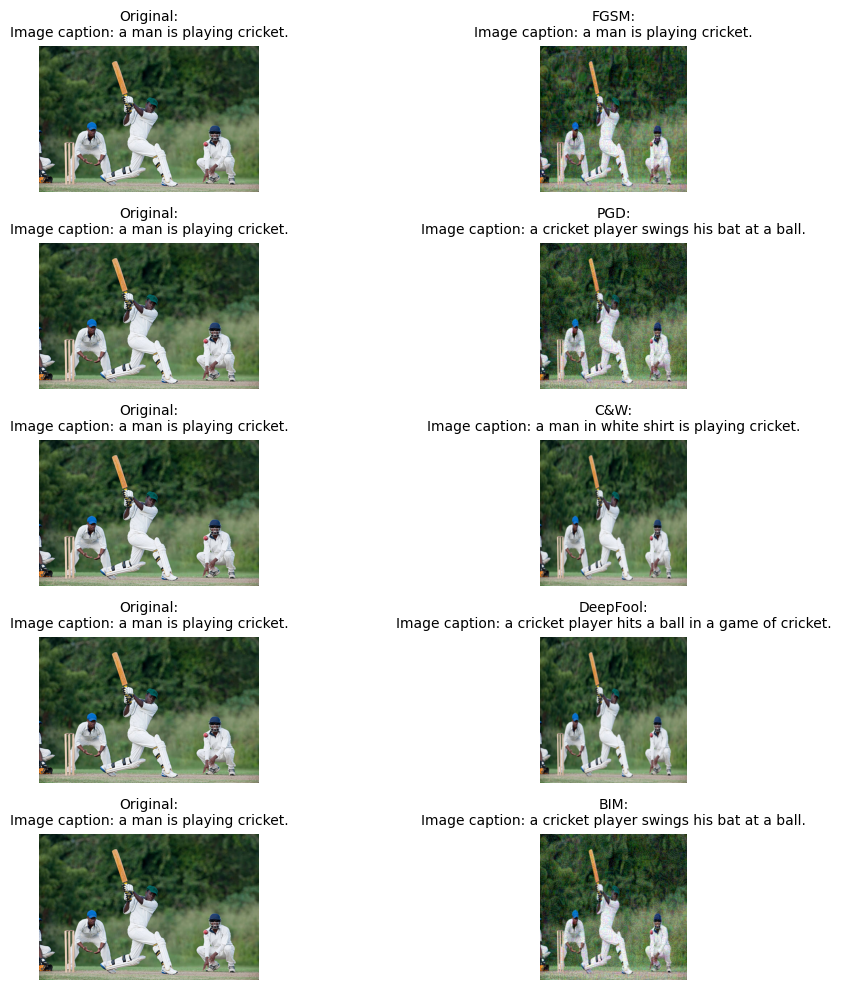

In [4]:
import matplotlib.pyplot as plt

# Function to display image with caption
def show_image_with_caption(image, title):
    plt.imshow(image)
    plt.title(title, fontsize=10)
    plt.axis('off')

# === CAPTIONS ===
original_img = Image.open(image_path).convert("RGB")
original_caption = generate_refined_caption(original_img)
fgsm_caption = generate_refined_caption(attacked_img)
pgd_caption = generate_refined_caption(pgd_img)
cw_caption = generate_refined_caption(cw_img)
deepfool_caption = generate_refined_caption(deepfool_img)
bim_caption = generate_refined_caption(bim_img)

# === DISPLAY IMAGES SIDE-BY-SIDE ===
attacks = [
    ("FGSM", attacked_img, fgsm_caption),
    ("PGD", pgd_img, pgd_caption),
    ("C&W", cw_img, cw_caption),
    ("DeepFool", deepfool_img, deepfool_caption),
    ("BIM", bim_img, bim_caption)
]

plt.figure(figsize=(12, 10))
for i, (attack_name, attack_img, attack_caption) in enumerate(attacks):
    # Original image
    plt.subplot(len(attacks), 2, 2*i + 1)
    show_image_with_caption(original_img, f"Original:\n{original_caption}")

    # Attacked image
    plt.subplot(len(attacks), 2, 2*i + 2)
    show_image_with_caption(attack_img, f"{attack_name}:\n{attack_caption}")

plt.tight_layout()
plt.show()
